# OOD generalization

Load a probe trained on one tree dataset setting and evaluate the frozen probe on a second tree dataset setting.

This notebook:
- loads a stored probe artifact from the source dataset
- rebuilds target-layer encodings from cached responses and embeddings
- applies the source distance probe and source depth regressor to the target dataset
- plots in-distribution and OOD metrics across layers in the same style as `probe-statistics.ipynb`

For normalized probes, OOD scores are evaluated in the source probe's label space by default. Set `OOD_NORMALIZATION = "target"` below if you want target-relative normalization instead.

In [14]:
# Parameters
SOURCE_DEPTH_RANGE = [1, 2]
SOURCE_STEPS_RANGE = [1, 2]
SOURCE_SPARSITY_RANGE = None

TARGET_DEPTH_RANGE = [3, 4]
TARGET_STEPS_RANGE = [1, 2]
TARGET_SPARSITY_RANGE = [0.5, 1]

NUM_SAMPLES = 1000
MODEL_TAG = "DeepSeek-R1-Distill-Qwen-14B"
PROJ_DIM = 5
PCA_COMPONENTS = 10
NORMALIZED = False
OOD_NORMALIZATION = "source"  # "source" or "target"
SHOW_TARGET_ALL = False
TOP_K_LAYERS = 8

In [15]:
from dataclasses import dataclass
from pathlib import Path
import json
import sys
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

NOTEBOOK_DIR = Path.cwd().resolve()
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "cutter").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cutter/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from cutter.utils.shared import paths as path_utils
from cutter.utils.shared.embeddings_cache import load_embedding_payload
from cutter.utils.tree.trees import pairwise_tree_distances, tree_depth

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
POINCARE_EPS = 1e-5


In [16]:
@dataclass
class ResponseRecord:
    example_id: int
    depth: int
    source: int
    target: int
    num_samples: int
    prompt: str
    ground_truth_path: List[int]
    canonical_path: List[int]
    canonical_source: int
    canonical_target: int
    label_mapping: List[int]
    raw: str
    parsed_path: List[int]
    parsed_text: Optional[str]
    format_ok: bool
    exact_match: bool
    partial_score: float

    @classmethod
    def from_json(cls, row: Mapping[str, Any]) -> "ResponseRecord":
        return cls(
            example_id=int(row.get("example_id", -1)),
            depth=int(row["depth"]),
            source=int(row["source"]),
            target=int(row["target"]),
            num_samples=int(row.get("num_samples", row.get("sample_rate", -1))),
            prompt=str(row["prompt"]),
            ground_truth_path=[int(x) for x in row["ground_truth_path"]],
            canonical_path=[int(x) for x in row.get("canonical_path", row.get("ground_truth_path", []))],
            canonical_source=int(row.get("canonical_source", row.get("source", -1))),
            canonical_target=int(row.get("canonical_target", row.get("target", -1))),
            label_mapping=[int(x) for x in row.get("label_mapping", [])],
            raw=str(row.get("model_raw", "")),
            parsed_path=[int(x) for x in row.get("parsed_path", [])],
            parsed_text=row.get("parsed_text"),
            format_ok=bool(row.get("format_ok", False)),
            exact_match=bool(row.get("exact_match", False)),
            partial_score=float(row.get("partial_score", 0.0)),
        )


def load_responses(path: Path) -> List[ResponseRecord]:
    records: List[ResponseRecord] = []
    with path.open("r", encoding="utf-8") as fh:
        for idx, line in enumerate(fh):
            if not line.strip():
                continue
            rec = ResponseRecord.from_json(json.loads(line))
            if rec.example_id < 0:
                rec.example_id = idx
            records.append(rec)
    return records


def load_embedding_cache(path: Path) -> tuple[Dict[int, Dict[str, Any]], Dict[str, Any]]:
    return load_embedding_payload(path)


def _invert_mapping(mapping: Sequence[int]) -> Dict[int, int]:
    return {label: idx for idx, label in enumerate(mapping)}


def build_layer_from_cache(
    train_records: Sequence[ResponseRecord],
    test_records: Sequence[ResponseRecord],
    layer_idx: int,
    cache: Mapping[int, Any],
) -> Optional[Dict[str, Any]]:
    holder = {
        "X_list": [],
        "depth_list": [],
        "node_ids": [],
        "example_ids": [],
        "example_accuracy": [],
        "example_depths": [],
        "train_idx": [],
        "test_idx": [],
        "example_is_exact": [],
    }
    for split_name, records in (("train", train_records), ("test", test_records)):
        for rec in records:
            if not rec.parsed_path:
                continue
            emb_entry = cache.get(rec.example_id)
            if emb_entry is None:
                continue
            inv_map = _invert_mapping(rec.label_mapping) if rec.label_mapping else None

            def _to_canonical(node_id: int) -> int:
                if inv_map is None:
                    return node_id
                return inv_map.get(node_id, node_id)

            canonical_parsed = [_to_canonical(nid) for nid in rec.parsed_path]
            depth_vals_full = [tree_depth(nid) for nid in canonical_parsed]
            layers_dict = emb_entry["embeddings_by_layer"] if isinstance(emb_entry, dict) else emb_entry.embeddings_by_layer
            emb = layers_dict.get(layer_idx)
            if emb is None or emb.size == 0:
                continue
            count = emb.shape[0]
            effective_count = min(count, len(rec.parsed_path))
            if effective_count == 0:
                continue
            path_nodes = canonical_parsed[:effective_count]
            depth_vals = depth_vals_full[:effective_count]
            if effective_count != count:
                emb = np.asarray(emb, dtype=np.float32)[:effective_count]
                count = effective_count
            holder["X_list"].append(np.asarray(emb, dtype=np.float32))
            holder["depth_list"].extend(depth_vals)
            holder["node_ids"].extend(path_nodes)
            holder["example_ids"].extend([rec.example_id] * count)
            holder["example_accuracy"].extend([float(rec.partial_score)] * count)
            holder["example_depths"].extend([rec.depth] * count)
            holder["example_is_exact"].extend([bool(rec.exact_match)] * count)
            if split_name == "train":
                start = len(holder["train_idx"]) + len(holder["test_idx"])
                holder["train_idx"].extend(range(start, start + count))
            else:
                start = len(holder["train_idx"]) + len(holder["test_idx"])
                holder["test_idx"].extend(range(start, start + count))

    if not holder["X_list"]:
        return None
    X = np.vstack(holder["X_list"]).astype(np.float32)
    return {
        "X": X,
        "depth": np.array(holder["depth_list"], dtype=np.float32),
        "node_ids": np.array(holder["node_ids"], dtype=np.int64),
        "example_ids": np.array(holder["example_ids"], dtype=np.int64),
        "example_accuracy": np.array(holder["example_accuracy"], dtype=np.float32),
        "example_depths": np.array(holder["example_depths"], dtype=np.int64),
        "example_is_exact": np.array(holder["example_is_exact"], dtype=bool),
        "train_idx": np.array(holder["train_idx"], dtype=int),
        "test_idx": np.array(holder["test_idx"], dtype=int),
    }


def _project_to_poincare_ball(points: np.ndarray, eps: float = POINCARE_EPS) -> np.ndarray:
    norms = np.linalg.norm(points, axis=-1, keepdims=True)
    max_norm = 1.0 - eps
    scale = np.ones_like(norms)
    mask = norms >= max_norm
    safe_norms = np.where(mask, norms, np.ones_like(norms))
    scale[mask] = max_norm / np.clip(safe_norms[mask], eps, None)
    return points * scale


def _project_to_ball(points: np.ndarray, curvature: float, eps: float = POINCARE_EPS) -> np.ndarray:
    points = np.asarray(points, dtype=np.float32)
    radius = 1.0 / np.sqrt(max(curvature, eps))
    max_norm = radius - eps
    norms = np.linalg.norm(points, axis=-1, keepdims=True)
    scale = np.ones_like(norms)
    mask = norms >= max_norm
    safe_norms = np.where(mask, norms, np.ones_like(norms))
    scale[mask] = max_norm / np.clip(safe_norms[mask], eps, None)
    return points * scale


def _mobius_add(x: np.ndarray, y: np.ndarray, curvature: float, eps: float = POINCARE_EPS) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    if x.ndim < y.ndim:
        x = np.expand_dims(x, axis=0)
    if x.shape != y.shape:
        x = np.broadcast_to(x, y.shape)
    xy = np.sum(x * y, axis=-1, keepdims=True)
    x2 = np.sum(x * x, axis=-1, keepdims=True)
    y2 = np.sum(y * y, axis=-1, keepdims=True)
    numerator = (1 + 2 * curvature * xy + curvature * y2) * x + (1 - curvature * x2) * y
    denominator = 1 + 2 * curvature * xy + (curvature ** 2) * x2 * y2
    return numerator / np.clip(denominator, eps, None)


def _pairwise_euclidean(points: np.ndarray) -> np.ndarray:
    squared = np.sum(points ** 2, axis=1, keepdims=True)
    distances_sq = squared + squared.T - 2 * (points @ points.T)
    distances_sq = np.clip(distances_sq, 0.0, None)
    return np.sqrt(distances_sq + 1e-9)


def _pairwise_poincare(
    points: np.ndarray,
    *,
    center: Optional[np.ndarray] = None,
    curvature: Optional[float] = None,
    eps: float = POINCARE_EPS,
) -> np.ndarray:
    points = np.asarray(points, dtype=np.float32)
    if curvature is None and center is None:
        projected = _project_to_poincare_ball(points, eps=eps)
        squared_norms = np.sum(projected ** 2, axis=1, keepdims=True)
        diff_sq = np.clip(squared_norms + squared_norms.T - 2 * (projected @ projected.T), 0.0, None)
        denom = np.clip((1.0 - squared_norms) * (1.0 - squared_norms.T), eps, None)
        arg = 1.0 + 2.0 * diff_sq / denom
        arg = np.clip(arg, 1.0 + eps, None)
        np.fill_diagonal(arg, 1.0)
        distances = np.arccosh(arg)
        np.fill_diagonal(distances, 0.0)
        return distances

    curvature_value = 1.0 if curvature is None else float(curvature)
    transformed = _project_to_ball(points, curvature_value, eps=eps)
    if center is not None:
        center_projected = _project_to_ball(np.asarray(center, dtype=np.float32), curvature_value, eps=eps)
        transformed = _mobius_add(center_projected, transformed, curvature_value, eps=eps)
    sqrt_c = np.sqrt(curvature_value)
    unit_points = _project_to_poincare_ball(transformed * sqrt_c, eps=eps)
    distances = _pairwise_poincare(unit_points, eps=eps)
    return distances / sqrt_c


def pairwise_distance(
    points: np.ndarray,
    geometry: str,
    *,
    center: Optional[np.ndarray] = None,
    curvature: Optional[float] = None,
) -> np.ndarray:
    geometry = geometry.lower()
    if geometry == "euclidean":
        return _pairwise_euclidean(np.asarray(points, dtype=np.float32))
    if geometry == "hyperbolic":
        return _pairwise_poincare(np.asarray(points, dtype=np.float32), center=center, curvature=curvature)
    raise ValueError(f"Unsupported geometry '{geometry}'")


def _parse_int_range(values: Iterable[int] | int, name: str, min_value: int = 1) -> tuple[int, int]:
    if isinstance(values, (int, float)):
        values = [int(values)]
    values = list(values)
    if len(values) == 1:
        range_min = range_max = int(values[0])
    elif len(values) == 2:
        range_min, range_max = [int(v) for v in values]
    else:
        raise ValueError(f"{name} must have length 1 or 2")
    if range_min < min_value or range_max < min_value or range_max < range_min:
        raise ValueError(f"{name} must satisfy {min_value} <= min <= max")
    return range_min, range_max


def _parse_float_range(values: Optional[Iterable[float] | float], name: str) -> Optional[tuple[float, float]]:
    if values is None:
        return None
    if isinstance(values, (int, float)):
        values = [float(values)]
    values = list(values)
    if len(values) == 1:
        range_min = range_max = float(values[0])
    elif len(values) == 2:
        range_min, range_max = [float(v) for v in values]
    else:
        raise ValueError(f"{name} must have length 1 or 2")
    if range_min <= 0 or range_max <= 0 or range_max < range_min:
        raise ValueError(f"{name} must satisfy 0 < min <= max")
    return range_min, range_max


def _dataset_tag(depth_range, steps_range, sparsity_range, num_samples: int) -> str:
    min_depth, max_depth = _parse_int_range(depth_range, "depth_range")
    min_steps, max_steps = _parse_int_range(steps_range, "steps_range")
    sparsity = _parse_float_range(sparsity_range, "sparsity_range")
    step_value: int | tuple[int, int] = min_steps if min_steps == max_steps else (min_steps, max_steps)
    return path_utils.dataset_tag(
        min_depth,
        max_depth,
        num_samples,
        num_steps=step_value,
        sparsity=sparsity,
    )


def _results_path(dataset_tag: str) -> Path:
    return path_utils.probe_path(dataset_tag, MODEL_TAG, PROJ_DIM, NORMALIZED, PCA_COMPONENTS)


def _resolve_probe_projection(res: Dict[str, Any]) -> np.ndarray:
    if isinstance(res.get("distance"), dict) and res["distance"].get("projection") is not None:
        return np.asarray(res["distance"]["projection"], dtype=np.float32)
    projection = res.get("projection")
    if projection is None:
        raise ValueError("No saved distance projection found in probe artifact")
    return np.asarray(projection, dtype=np.float32)


def _resolve_depth_model(res: Dict[str, Any]):
    depth_block = res.get("depth", {}) if isinstance(res, dict) else {}
    if isinstance(depth_block, dict) and depth_block.get("model") is not None:
        return depth_block["model"]
    return res.get("depth_model")


def _restore_from_target_pca(features: np.ndarray, layer: int, target_meta: Dict[str, Any]) -> np.ndarray:
    pca_info = target_meta.get("pca") if isinstance(target_meta, dict) else None
    if not isinstance(pca_info, dict):
        return features
    layer_info = pca_info.get(layer)
    if not isinstance(layer_info, dict):
        return features
    components = np.asarray(layer_info.get("components", []), dtype=np.float32)
    mean = np.asarray(layer_info.get("mean", 0.0), dtype=np.float32)
    if components.size == 0:
        return features
    if features.shape[1] == components.shape[0]:
        return features @ components + mean
    return features


def _apply_source_pca(features: np.ndarray, res: Dict[str, Any]) -> np.ndarray:
    pca = res.get("pca") if isinstance(res, dict) else None
    if not pca:
        return features
    components = np.asarray(pca.get("components", []), dtype=np.float32)
    mean = np.asarray(pca.get("mean", 0.0), dtype=np.float32)
    if components.size == 0:
        return features
    if features.shape[1] == components.shape[1]:
        return (features - mean) @ components.T
    if features.shape[1] == components.shape[0]:
        return features
    raise ValueError(
        f"Target embedding width {features.shape[1]} is incompatible with source PCA {components.shape}"
    )


def _prepare_target_features(features: np.ndarray, layer: int, res: Dict[str, Any], target_meta: Dict[str, Any]) -> np.ndarray:
    restored = _restore_from_target_pca(features, layer, target_meta)
    return _apply_source_pca(restored, res)


def _pair_corr(true_mat: np.ndarray, pred_mat: np.ndarray, mask: np.ndarray) -> float:
    tri_mask = np.triu(mask, k=1).astype(bool)
    if not tri_mask.any():
        return float("nan")
    true_vals = true_mat[tri_mask]
    pred_vals = pred_mat[tri_mask]
    if true_vals.size < 2:
        return float("nan")
    return float(np.corrcoef(true_vals, pred_vals)[0, 1])


def _pair_mse(true_mat: np.ndarray, pred_mat: np.ndarray, mask: np.ndarray) -> float:
    tri_mask = np.triu(mask, k=1).astype(bool)
    if not tri_mask.any():
        return float("nan")
    true_vals = true_mat[tri_mask]
    pred_vals = pred_mat[tri_mask]
    return float(np.mean((true_vals - pred_vals) ** 2)) if true_vals.size else float("nan")


def _depth_metrics(true_vals: np.ndarray, pred_vals: np.ndarray) -> Dict[str, float]:
    if true_vals.size == 0 or pred_vals.size == 0:
        return {"pearson": float("nan"), "mse": float("nan")}
    mse = float(np.mean((true_vals - pred_vals) ** 2))
    if true_vals.size < 2 or np.allclose(true_vals, true_vals[0]) or np.allclose(pred_vals, pred_vals[0]):
        pearson = float("nan")
    else:
        pearson = float(np.corrcoef(true_vals, pred_vals)[0, 1])
    return {"pearson": pearson, "mse": mse}


def _source_normalization_factor(res: Dict[str, Any], meta: Dict[str, Any]) -> Optional[float]:
    depth_block = res.get("depth", {}) if isinstance(res, dict) else {}
    if isinstance(depth_block, dict):
        value = depth_block.get("normalization_factor")
        if value:
            return float(value)
    return None if not meta.get("normalize_tree", False) else None


def _target_normalization_factor(data: Dict[str, Any]) -> Optional[float]:
    depth = np.asarray(data.get("depth", []), dtype=np.float32)
    if depth.size == 0:
        return None
    value = float(np.max(depth))
    return value if value > 0 else None


def _resolve_normalization_factor(data: Dict[str, Any], res: Dict[str, Any], meta: Dict[str, Any], mode: str) -> Optional[float]:
    normalized = bool(res.get("normalized_tree", meta.get("normalize_tree", False)))
    if not normalized:
        return None
    if mode == "source":
        value = _source_normalization_factor(res, meta)
        if value is not None:
            return value
    if mode == "target":
        value = _target_normalization_factor(data)
        if value is not None:
            return value
    return _target_normalization_factor(data)


def _evaluate_frozen_probe(
    data: Dict[str, Any],
    layer: int,
    res: Dict[str, Any],
    meta: Dict[str, Any],
    normalization_mode: str,
    target_meta: Dict[str, Any],
) -> Dict[str, Any]:
    X = np.asarray(data["X"], dtype=np.float32)
    dist_true = np.asarray(data["dist"], dtype=np.float32)
    depth_true = np.asarray(data["depth"], dtype=np.float32)
    example_ids = np.asarray(data.get("example_ids", []), dtype=np.int64)
    exact_mask = np.asarray(data.get("example_is_exact", np.ones(len(depth_true), dtype=bool)), dtype=bool)

    norm_factor = _resolve_normalization_factor(data, res, meta, normalization_mode)
    if norm_factor:
        dist_eval = dist_true / norm_factor
        depth_eval = depth_true / norm_factor
    else:
        dist_eval = dist_true
        depth_eval = depth_true

    projection = _resolve_probe_projection(res)
    geometry = str(res.get("geometry", meta.get("fit_geometry", "euclidean"))).lower()
    center = res.get("center")
    curvature = res.get("curvature")

    X_feat = _prepare_target_features(X, layer, res, target_meta)
    Z_raw = X_feat @ projection
    dist_pred = pairwise_distance(Z_raw, geometry, center=center, curvature=curvature)

    depth_model = _resolve_depth_model(res)
    if depth_model is not None:
        depth_pred = depth_model.predict(X_feat)
    else:
        depth_pred = np.full_like(depth_eval, np.nan, dtype=np.float32)

    pair_mask = example_ids[:, None] == example_ids[None, :]
    np.fill_diagonal(pair_mask, False)
    exact_pair_mask = np.outer(exact_mask, exact_mask) & pair_mask
    inexact_pair_mask = np.outer(~exact_mask, ~exact_mask) & pair_mask

    return {
        "distance": {
            "target_all": {
                "pearson": _pair_corr(dist_eval, dist_pred, pair_mask),
                "mse": _pair_mse(dist_eval, dist_pred, pair_mask),
            },
            "target_exact": {
                "pearson": _pair_corr(dist_eval, dist_pred, exact_pair_mask),
                "mse": _pair_mse(dist_eval, dist_pred, exact_pair_mask),
            },
            "target_inexact": {
                "pearson": _pair_corr(dist_eval, dist_pred, inexact_pair_mask),
                "mse": _pair_mse(dist_eval, dist_pred, inexact_pair_mask),
            },
        },
        "depth": {
            "target_all": _depth_metrics(depth_eval, depth_pred),
            "target_exact": _depth_metrics(depth_eval[exact_mask], depth_pred[exact_mask]),
            "target_inexact": _depth_metrics(depth_eval[~exact_mask], depth_pred[~exact_mask]),
        },
        "normalization_factor": norm_factor,
        "target_examples": int(len(np.unique(example_ids))) if example_ids.size else 0,
    }


def _build_target_layer_encoding(layer: int, records, cache) -> Optional[Dict[str, Any]]:
    data = build_layer_from_cache([], records, layer, cache)
    if data is None:
        return None
    node_ids = np.asarray(data.get("node_ids", []), dtype=np.int64)
    data["dist"] = pairwise_tree_distances(node_ids)
    return data


def _collect_target_results(results: Dict[int, Any], records, cache, target_meta: Dict[str, Any], meta: Dict[str, Any]) -> Dict[int, Any]:
    target_results: Dict[int, Any] = {}
    for layer in sorted(results):
        data = _build_target_layer_encoding(layer, records, cache)
        if data is None:
            continue
        target_results[layer] = _evaluate_frozen_probe(data, layer, results[layer], meta, OOD_NORMALIZATION, target_meta)
    return target_results


def _source_metric_rows(results: Dict[int, Any]) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    source_splits = {
        "source_train": ("train", "dist_corr_train", "dist_mse_train"),
        "source_test_exact": ("test_exact", "dist_corr_test_exact", "dist_mse_test_exact"),
        "source_test_inexact": ("test_inexact", "dist_corr_test_inexact", "dist_mse_test_inexact"),
    }
    for layer, res in sorted(results.items()):
        for split_label, (depth_split, dist_corr_key, dist_mse_key) in source_splits.items():
            rows.append(
                {
                    "layer": layer,
                    "metric": "distance",
                    "split": split_label,
                    "pearson": float(res.get(dist_corr_key, np.nan)),
                    "mse": float(res.get(dist_mse_key, np.nan)),
                }
            )
            depth_block = res.get("depth", {}) if isinstance(res, dict) else {}
            depth_split_block = depth_block.get(depth_split, {}) if isinstance(depth_block, dict) else {}
            rows.append(
                {
                    "layer": layer,
                    "metric": "depth",
                    "split": split_label,
                    "pearson": float(depth_split_block.get("pearson", np.nan)),
                    "mse": float(depth_split_block.get("mse", np.nan)),
                }
            )
    return rows


def _target_metric_rows(target_results: Dict[int, Any]) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    for layer, res in sorted(target_results.items()):
        for split in ["target_all", "target_exact", "target_inexact"]:
            rows.append(
                {
                    "layer": layer,
                    "metric": "distance",
                    "split": split,
                    "pearson": float(res["distance"][split]["pearson"]),
                    "mse": float(res["distance"][split]["mse"]),
                }
            )
            rows.append(
                {
                    "layer": layer,
                    "metric": "depth",
                    "split": split,
                    "pearson": float(res["depth"][split]["pearson"]),
                    "mse": float(res["depth"][split]["mse"]),
                }
            )
    return rows


def _summary_table(target_results: Dict[int, Any]) -> pd.DataFrame:
    rows = []
    for layer, res in sorted(target_results.items()):
        rows.append(
            {
                "layer": layer,
                "target_examples": res.get("target_examples", 0),
                "normalization_factor": res.get("normalization_factor"),
                "target_exact_distance_pearson": res["distance"]["target_exact"]["pearson"],
                "target_exact_distance_mse": res["distance"]["target_exact"]["mse"],
                "target_exact_depth_pearson": res["depth"]["target_exact"]["pearson"],
                "target_exact_depth_mse": res["depth"]["target_exact"]["mse"],
                "target_inexact_distance_pearson": res["distance"]["target_inexact"]["pearson"],
                "target_inexact_depth_pearson": res["depth"]["target_inexact"]["pearson"],
            }
        )
    return pd.DataFrame(rows)


In [17]:
SOURCE_DATASET_TAG = _dataset_tag(SOURCE_DEPTH_RANGE, SOURCE_STEPS_RANGE, SOURCE_SPARSITY_RANGE, NUM_SAMPLES)
TARGET_DATASET_TAG = _dataset_tag(TARGET_DEPTH_RANGE, TARGET_STEPS_RANGE, TARGET_SPARSITY_RANGE, NUM_SAMPLES)
SOURCE_RESULTS_PATH = _results_path(SOURCE_DATASET_TAG)
TARGET_RAW_EMBEDDINGS_PATH = path_utils.embeddings_path(TARGET_DATASET_TAG, MODEL_TAG)
TARGET_PCA_EMBEDDINGS_PATH = path_utils.embeddings_pca_path(TARGET_DATASET_TAG, MODEL_TAG, PCA_COMPONENTS)
TARGET_RESPONSES_PATH = path_utils.responses_path(TARGET_DATASET_TAG, MODEL_TAG)

if not SOURCE_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Source probe artifact not found: {SOURCE_RESULTS_PATH}")
if not TARGET_RESPONSES_PATH.exists():
    raise FileNotFoundError(f"Target responses not found: {TARGET_RESPONSES_PATH}")

if TARGET_RAW_EMBEDDINGS_PATH.exists():
    TARGET_CACHE_PATH = TARGET_RAW_EMBEDDINGS_PATH
    TARGET_CACHE_MODE = "raw"
elif TARGET_PCA_EMBEDDINGS_PATH.exists():
    TARGET_CACHE_PATH = TARGET_PCA_EMBEDDINGS_PATH
    TARGET_CACHE_MODE = "target-pca-approx"
else:
    raise FileNotFoundError(
        f"No target embeddings cache found at {TARGET_RAW_EMBEDDINGS_PATH} or {TARGET_PCA_EMBEDDINGS_PATH}"
    )

artifact = np.load(SOURCE_RESULTS_PATH, allow_pickle=True)
meta = artifact["meta"].item()
results = artifact["results"].item()

target_records = load_responses(TARGET_RESPONSES_PATH)
target_cache, target_cache_meta = load_embedding_cache(TARGET_CACHE_PATH)
target_results = _collect_target_results(results, target_records, target_cache, target_cache_meta, meta)

metrics_df = pd.DataFrame(_source_metric_rows(results) + _target_metric_rows(target_results))
summary_df = _summary_table(target_results)

print(f"Source dataset: {SOURCE_DATASET_TAG}")
print(f"Target dataset: {TARGET_DATASET_TAG}")
print(f"Loaded source artifact: {SOURCE_RESULTS_PATH}")
print(f"Loaded target records: {len(target_records)} from {TARGET_RESPONSES_PATH}")
print(f"Loaded target cache: {TARGET_CACHE_PATH} ({TARGET_CACHE_MODE})")
if TARGET_CACHE_MODE != "raw":
    print("Using target-local PCA inversion as an approximation before applying the source probe basis.")
print(f"Evaluated layers: {sorted(target_results)}")
metrics_df.head()


Source dataset: depth1-2_n1000_steps1-2
Target dataset: depth3-4_n1000_steps1-2_spars0.5-1
Loaded source artifact: /Users/cutterdawes/Desktop/Research/SPAR/HierarchicalProbes/cutter/data/depth1-2_n1000_steps1-2/models/DeepSeek-R1-Distill-Qwen-14B/probes/probe_proj5_pca10.npz
Loaded target records: 1000 from /Users/cutterdawes/Desktop/Research/SPAR/HierarchicalProbes/cutter/data/depth3-4_n1000_steps1-2_spars0.5-1/models/DeepSeek-R1-Distill-Qwen-14B/responses.jsonl
Loaded target cache: /Users/cutterdawes/Desktop/Research/SPAR/HierarchicalProbes/cutter/data/depth3-4_n1000_steps1-2_spars0.5-1/models/DeepSeek-R1-Distill-Qwen-14B/embeddings_pca10.npz (target-pca-approx)
Using target-local PCA inversion as an approximation before applying the source probe basis.
Evaluated layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]


,layer,metric,split,pearson,mse
0,0,distance,source_train,-0.252717,2.136229
1,0,depth,source_train,0.114615,0.538706
2,0,distance,source_test_exact,-0.253531,2.055205
3,0,depth,source_test_exact,0.127898,0.535600
4,0,distance,source_test_inexact,-0.190188,2.364743


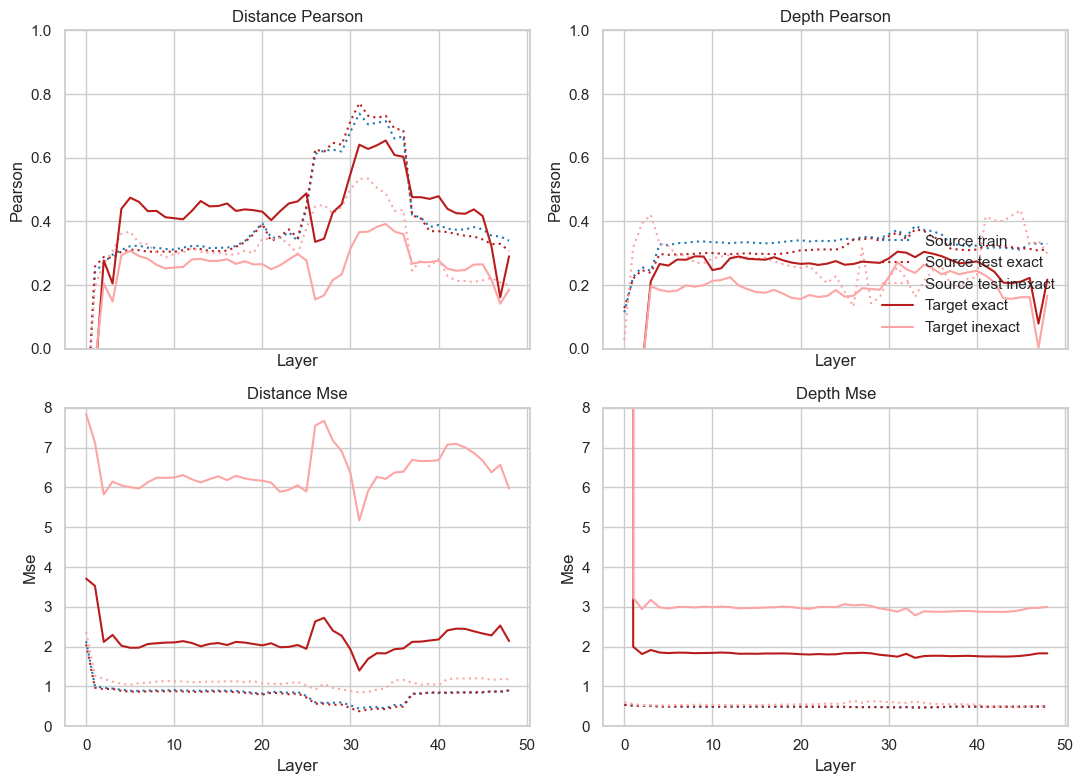

In [18]:
def plot_ood_layer_curves(df: pd.DataFrame, show_target_all: bool = False):
    split_order = [
        "source_train",
        "source_test_exact",
        "source_test_inexact",
        "target_exact",
        "target_inexact",
    ]
    if show_target_all:
        split_order.insert(3, "target_all")

    palette = {
        "source_train": "#1f77b4",
        "source_test_exact": "#b91c1c",
        "source_test_inexact": "#fca5a5",
        "target_all": "#ef4444",
        "target_exact": "#b91c1c",
        "target_inexact": "#fca5a5",
    }
    labels = {
        "source_train": "Source train",
        "source_test_exact": "Source test exact",
        "source_test_inexact": "Source test inexact",
        "target_all": "Target all",
        "target_exact": "Target exact",
        "target_inexact": "Target inexact",
    }
    dashes = {
        "source_train": (1, 2),
        "source_test_exact": (1, 2),
        "source_test_inexact": (1, 2),
        "target_all": (),
        "target_exact": (),
        "target_inexact": (),
    }

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex="col")
    rows = [("pearson", (0, 1)), ("mse", (0, 8))]
    metrics = ["distance", "depth"]

    for row_idx, (score_col, ylim) in enumerate(rows):
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            for split in split_order:
                subset = df[(df["metric"] == metric) & (df["split"] == split)].sort_values("layer")
                if subset.empty:
                    continue
                ax.plot(
                    subset["layer"],
                    subset[score_col],
                    color=palette[split],
                    label=labels[split],
                    dashes=dashes[split],
                )
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.set_title(f"{metric.title()} {score_col.title()}")
            ax.set_xlabel("Layer")
            ax.set_ylabel(score_col.title())

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    axes[0, 1].legend(handles, legend_labels, loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()


plot_ood_layer_curves(metrics_df, show_target_all=SHOW_TARGET_ALL)

In [19]:
summary_df.sort_values("target_exact_distance_pearson", ascending=False).head(TOP_K_LAYERS)

,layer,target_examples,normalization_factor,target_exact_distance_pearson,target_exact_distance_mse,target_exact_depth_pearson,target_exact_depth_mse,target_inexact_distance_pearson,target_inexact_depth_pearson
34,34,676,None,0.654291,1.830713,0.304677,1.762644,0.392349,0.264350
31,31,676,None,0.641135,1.399451,0.305037,1.748133,0.366644,0.271686
33,33,676,None,0.639148,1.835088,0.287825,1.718522,0.383106,0.238157
32,32,676,None,0.627795,1.692216,0.302051,1.819515,0.367825,0.250062
35,35,676,None,0.608711,1.935757,0.298832,1.771209,0.368500,0.252882
36,36,676,None,0.603166,1.955265,0.291216,1.770774,0.360091,0.233928
30,30,676,None,0.549702,1.927412,0.283787,1.773976,0.315168,0.224911
25,25,676,None,0.488227,1.945893,0.264205,1.835665,0.277570,0.164030


In [20]:
best_dist_layer = summary_df.sort_values("target_exact_distance_pearson", ascending=False).iloc[0]
best_depth_layer = summary_df.sort_values("target_exact_depth_pearson", ascending=False).iloc[0]

print(
    f"Best target exact distance layer: {int(best_dist_layer['layer'])} "
    f"(pearson={best_dist_layer['target_exact_distance_pearson']:.3f}, "
    f"mse={best_dist_layer['target_exact_distance_mse']:.3f})"
)
print(
    f"Best target exact depth layer: {int(best_depth_layer['layer'])} "
    f"(pearson={best_depth_layer['target_exact_depth_pearson']:.3f}, "
    f"mse={best_depth_layer['target_exact_depth_mse']:.3f})"
)

Best target exact distance layer: 34 (pearson=0.654, mse=1.831)
Best target exact depth layer: 31 (pearson=0.305, mse=1.748)
